In [11]:

import pandas as pd

df = pd.read_csv("../data/framingham.csv")

df.head(8)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0


Ahora que soy capaz de ver las columnas puedo sacar unas hipotesis iniciales para contrastarlas con las conclusiones finales del trabajo. 

HIPOTESIS INICIALES: 
1. la gente que fume tendra mas posibilidades de desarrollar una enfermedad cardiovascular
2. la gente que fume mas cigarros al dia sera incluso mas propensa a desarrolar una 
3. la gente que tenga diabetes tendra mas posibilidades de desarrollar una enfermedad
4. la gente con mayor heart rate sera mas propensa a desarrollar la enfermedad 
5. no creo que la educacion o si es hombre o mujer tenga un peso muy fuerte en ver si el paciente a desarrollado una enfermedad 

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [9]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


aqui veo muchas variables asi que pregunto cuales son categoricas y cuales son numericas ya que sospecho que algunas se podran cambiar de categoria mas adelante

se me ocurre la idea de separar male en male y female pero no creo que haga falta. 

Le pregunto a la IA el codigo para poder ver las variables en su categoria 

In [12]:
# ===============================
# IDENTIFICACIÓN DE VARIABLES
# ===============================

# Variables numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Variables categóricas reales
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Variables binarias (0/1)
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

# Mostrar resultados
print("🔢 Variables numéricas:")
print(numeric_cols)

print("\n🟢 Variables categóricas:")
print(categorical_cols)

print("\n⚫ Variables binarias:")
print(binary_cols)

🔢 Variables numéricas:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

🟢 Variables categóricas:
[]

⚫ Variables binarias:
['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


varias de estas se podran cambiar pero como he dicho se hara mas adelante 

Paso a hacer el primer analisis univariable para ver cada variable por si sola y analizarla 

In [ ]:
No tengo variables categoricas asique hago solo las numericas y despues las binarias  

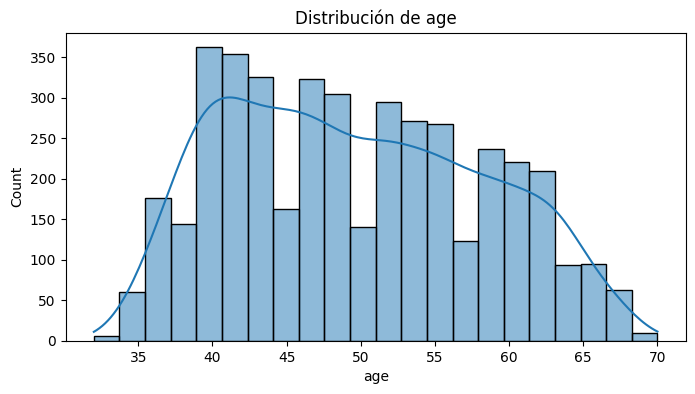

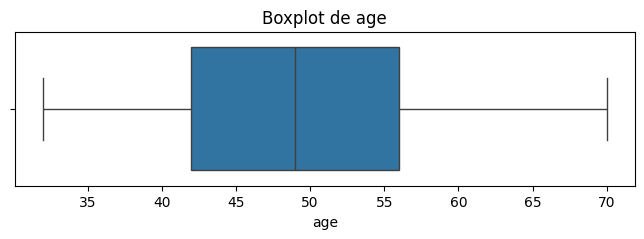

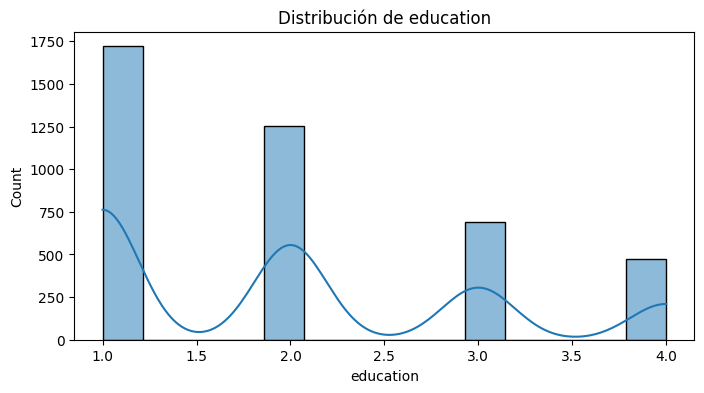

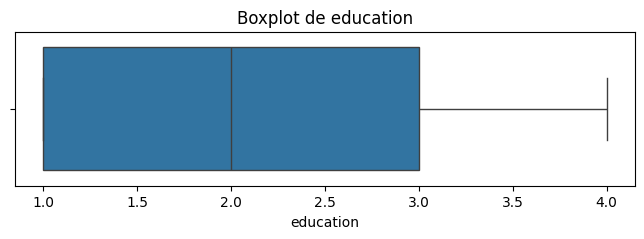

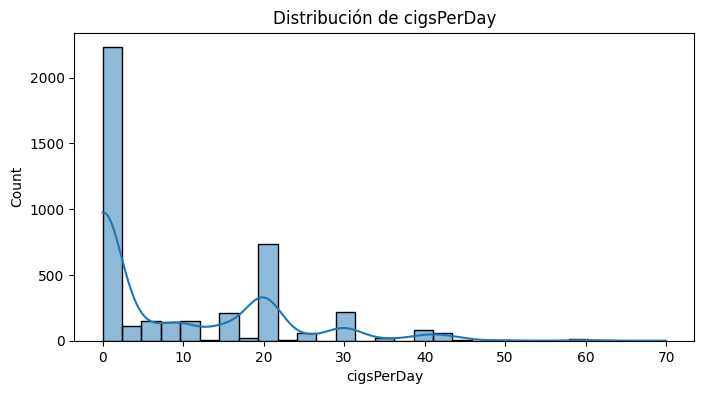

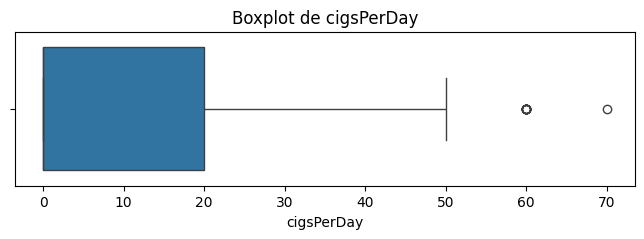

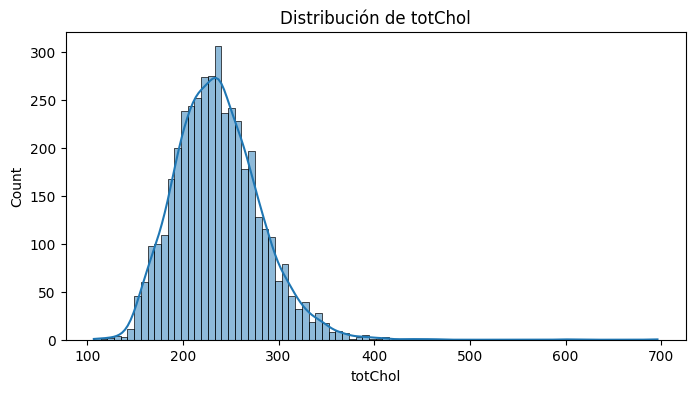

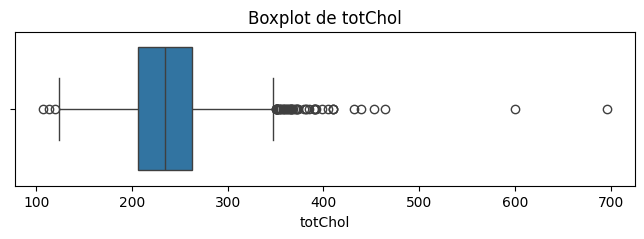

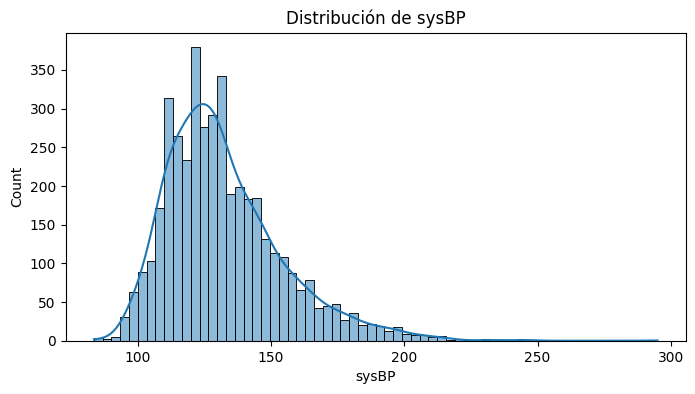

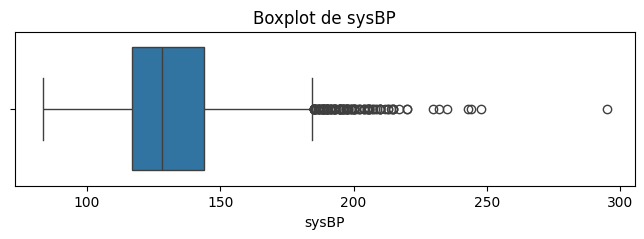

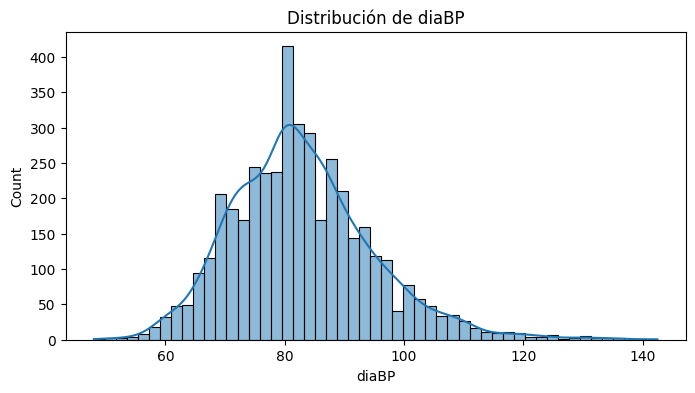

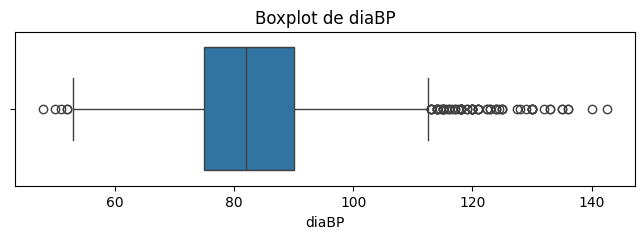

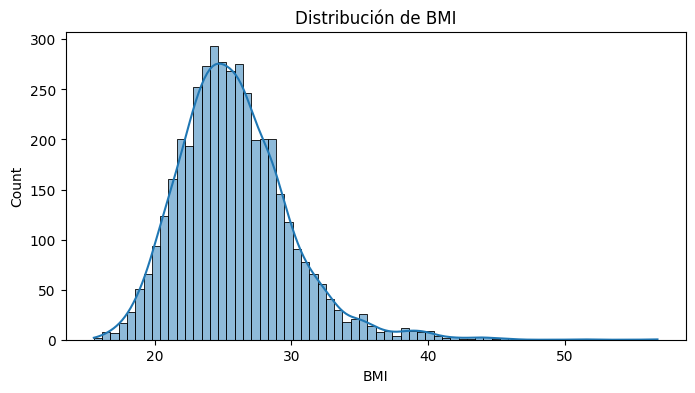

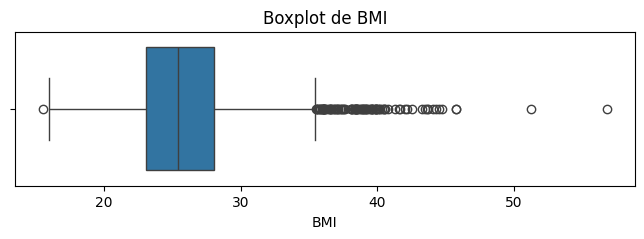

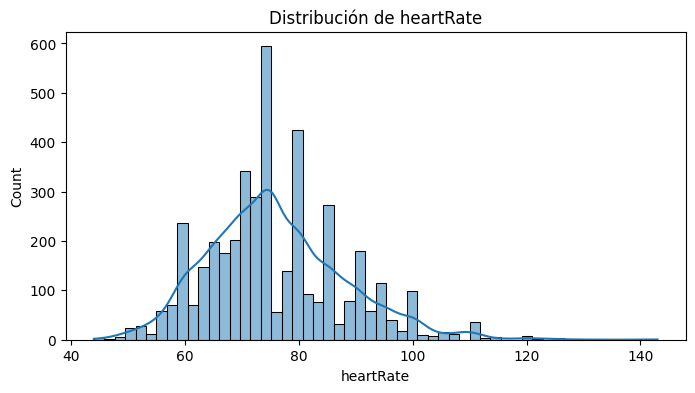

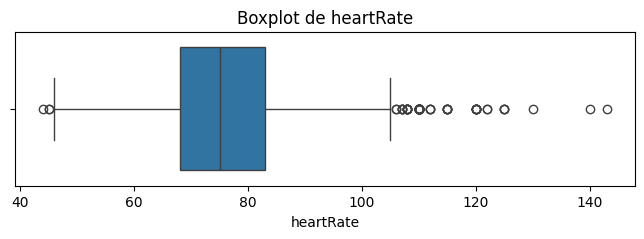

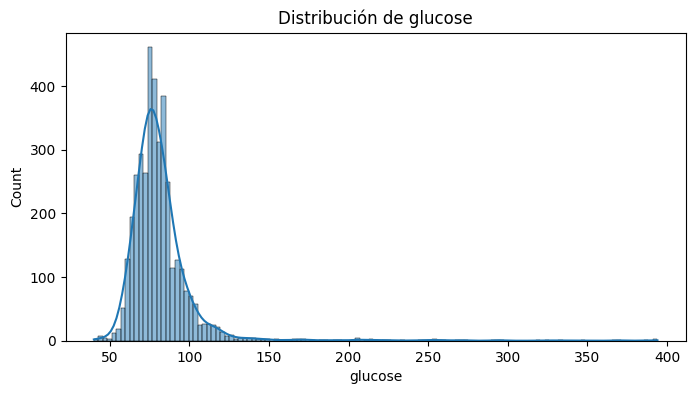

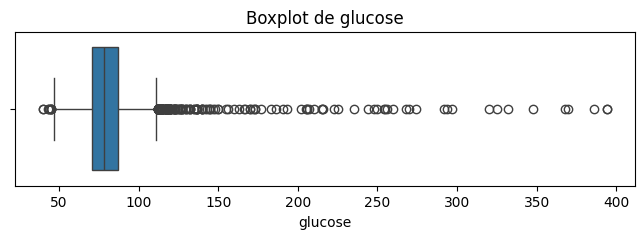

In [14]:
#analisis numericas

for col in numeric_cols:
    
    if col not in binary_cols:
        
        # Histograma
        plt.figure(figsize=(8,4))
        
        sns.histplot(df[col], kde=True)
        
        plt.title(f'Distribución de {col}')
        
        plt.show()
        
        
        # Boxplot
        plt.figure(figsize=(8,2))
        
        sns.boxplot(x=df[col])
        
        plt.title(f'Boxplot de {col}')
        
        plt.show()

ya hay ciertas cosas que podemos ir viendo en estos graficos como por ejemplo en cigarillos fumados en un dia hay un pico en 20 porque es el numero de cigarillos en una cajeta y despues la malloria de gente en 0 porque no fuman a secas. las variables de heartrate glucosa estan en un rango reducido de pulsaciones y de glucosa razonables para una persona normal pero detectamos bastante outliers. esto pasa en otras variables tambien 

ahora hacemos el de las binarias 

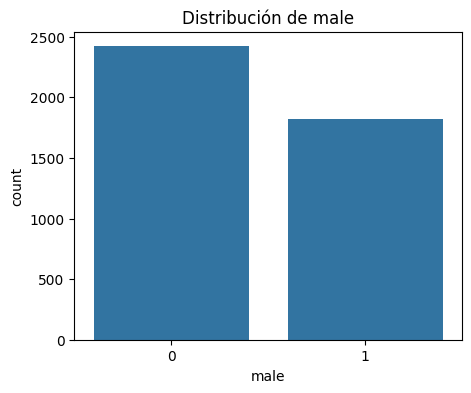

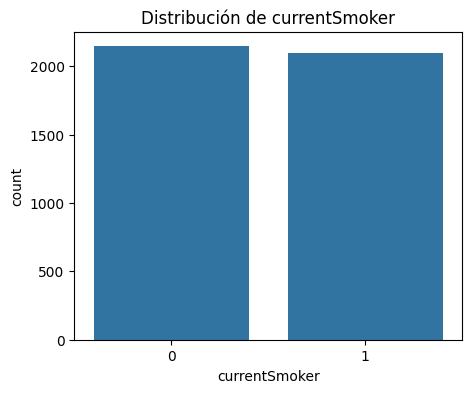

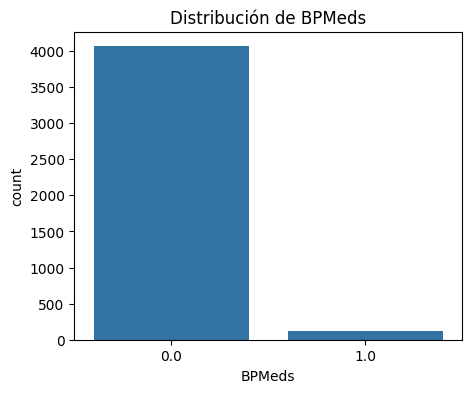

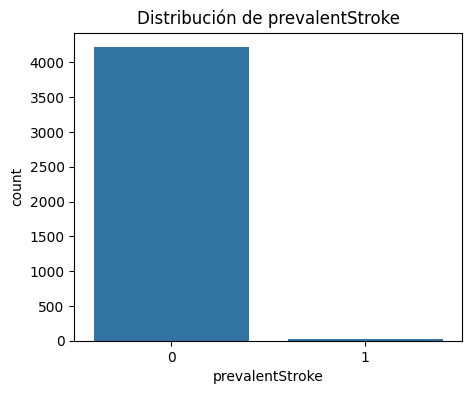

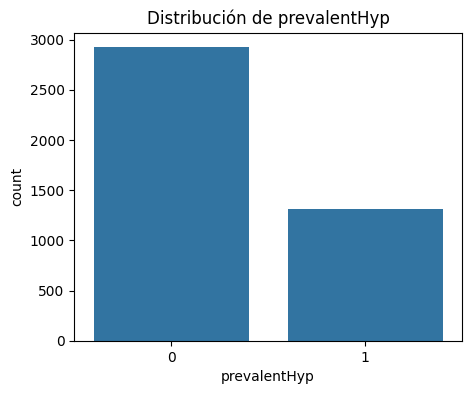

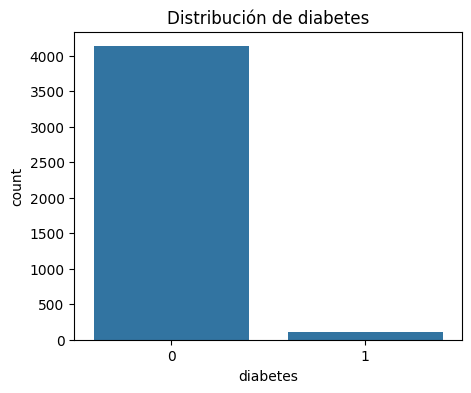

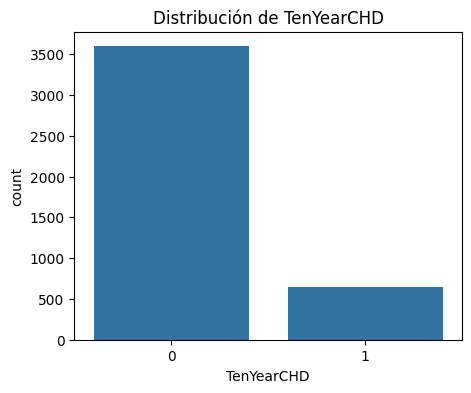

In [15]:
#ahora el de las binarias 

for col in binary_cols:
    
    plt.figure(figsize=(5,4))
    
    sns.countplot(x=df[col])
    
    plt.title(f'Distribución de {col}')
    
    plt.show()

aqui podemos ver basicamente diferencias entre la cantidad de personas que cumplen el 1 y el 0 siendo las variables que mas diferencia tienen la de desarrollar la enfermedad,la de diabetes, prevalent stroke y la gente que toma medicacion. 

ahora que ya hemos hecho el analisis univariable empezamos con el tratamiento de nulos, transformacion de datos y basicamente lo que viene a ser la limpieza de los datos 

In [16]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

la variable que mas nulos tiene es la de glucose. Esta variable tiene muchos outliers asi que los rellenaremos con la mediana que es mas resistente a estos que la media o la moda. heartrate, BMI y el total de colesterol seguiria esta misma logica (en cigs per day tambien pongo la mediana despues de preguntarle a la ia porque pensaba que lo mejor seria la media para tener en cuenta a la gente que fuma 0 que es la mayoria). la unica que se haria de manera diferente seria education y bpmeds que las hare con la moda. 

basado en mi analisis le pido a la ia que me lo traduzca al codigo 

In [ ]:
# ===============================
# TRATAMIENTO DE VALORES NULOS
# ===============================

# Mediana
df['glucose'] = df['glucose'].fillna(df['glucose'].median())

df['BMI'] = df['BMI'].fillna(df['BMI'].median())

df['totChol'] = df['totChol'].fillna(df['totChol'].median())

df['cigsPerDay'] = df['cigsPerDay'].fillna(df['cigsPerDay'].median())

df['heartRate'] = df['heartRate'].fillna(df['heartRate'].median())


# Moda
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].mode()[0])

df['education'] = df['education'].fillna(df['education'].mode()[0])

ahora que he hecho la limpieza de los nulos paso a transformar las variables binarias a categoricas ya que las variables que se miden en 1-0 es lo mismo que decir una etiqueta de si cumple o no cumple

hecho por ia

In [19]:
#conversion de las variables

df['male'] = df['male'].astype('object')

df['currentSmoker'] = df['currentSmoker'].astype('object')

df['BPMeds'] = df['BPMeds'].astype('object')

df['prevalentStroke'] = df['prevalentStroke'].astype('object')

df['prevalentHyp'] = df['prevalentHyp'].astype('object')

df['diabetes'] = df['diabetes'].astype('object')

df['TenYearCHD'] = df['TenYearCHD'].astype('object')


# ===============================
# ACTUALIZAR LISTAS DE COLUMNAS
# ===============================

binary_to_cat = [
    'male',
    'currentSmoker',
    'BPMeds',
    'prevalentStroke',
    'prevalentHyp',
    'diabetes',
    'TenYearCHD'
]

for col in binary_to_cat:
    
    numeric_cols.remove(col)
    
    categorical_cols.append(col)


# ===============================
# VARIABLES CATEGÓRICAS
# ===============================

df.describe(include='object')

,male,currentSmoker,BPMeds,prevalentStroke,prevalentHyp,diabetes,TenYearCHD
count,4240,4240,4240.0,4240,4240,4240,4240
unique,2,2,2.0,2,2,2,2
top,0,0,0.0,0,0,0,0
freq,2420,2145,4116.0,4215,2923,4131,3596


ahora vamos a tratar esos outliers mas bestias que no pueden dejarse sin tratar. hacemos una windsorizacion selectiva de los outliers para reducir esos extremos. 

hecho con ia

In [35]:
# cigsPerDay
limite_cigs = df['cigsPerDay'].quantile(0.95)

df['cigsPerDay'] = np.where(
    df['cigsPerDay'] > limite_cigs,
    limite_cigs,
    df['cigsPerDay']
)


# glucose
limite_glucose = df['glucose'].quantile(0.99)

df['glucose'] = np.where(
    df['glucose'] > limite_glucose,
    limite_glucose,
    df['glucose']
)


# BMI
limite_BMI = df['BMI'].quantile(0.99)

df['BMI'] = np.where(
    df['BMI'] > limite_BMI,
    limite_BMI,
    df['BMI']
)


# totChol
limite_totChol = df['totChol'].quantile(0.99)

df['totChol'] = np.where(
    df['totChol'] > limite_totChol,
    limite_totChol,
    df['totChol']
)

ahora que hemos limpiado los nulos y transformado las variables vuelvo a hacer el analisis univariable de todas las variables

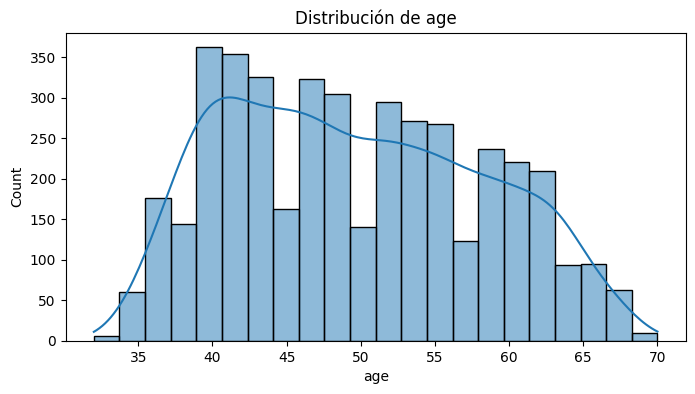

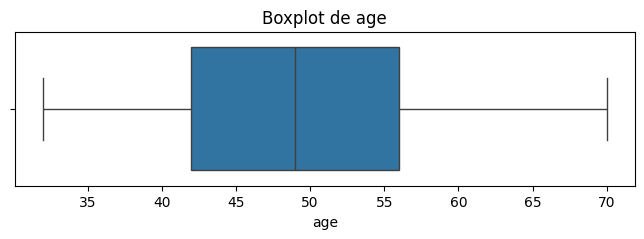

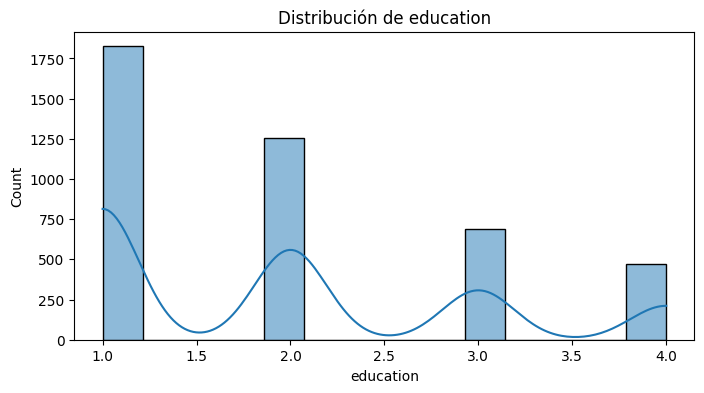

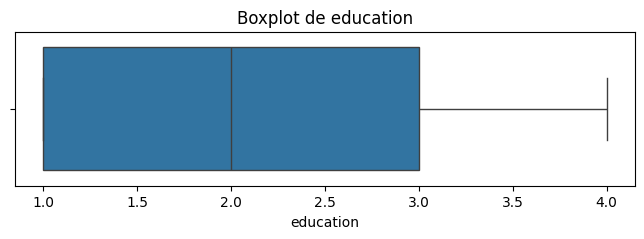

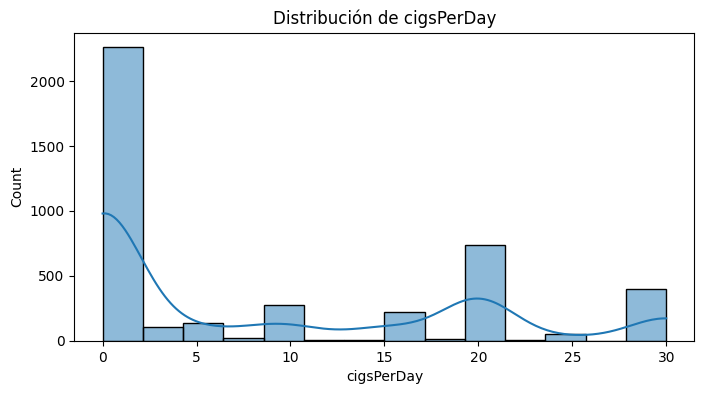

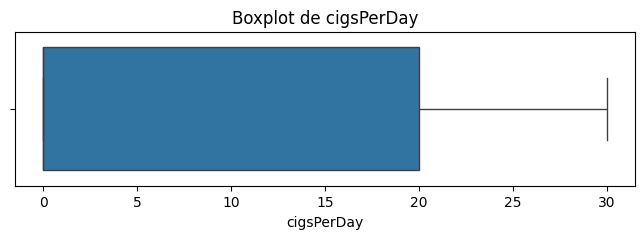

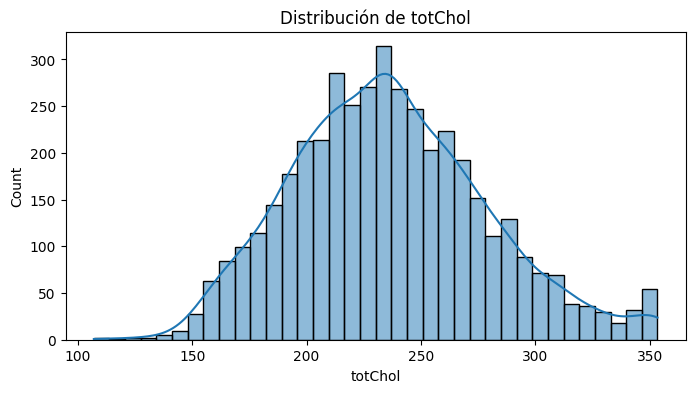

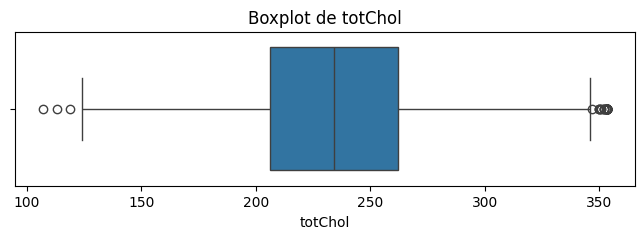

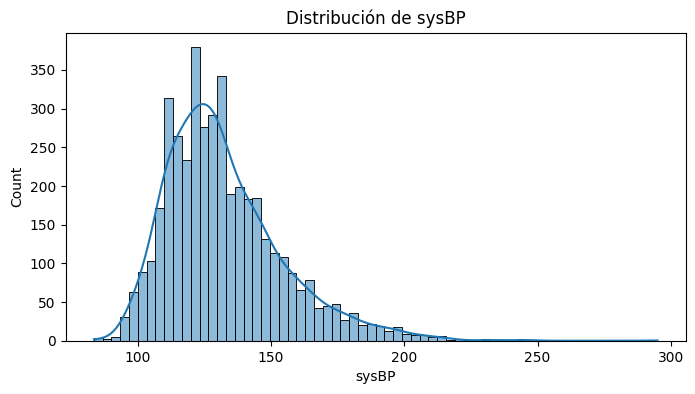

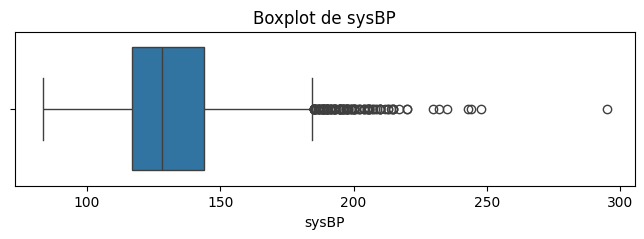

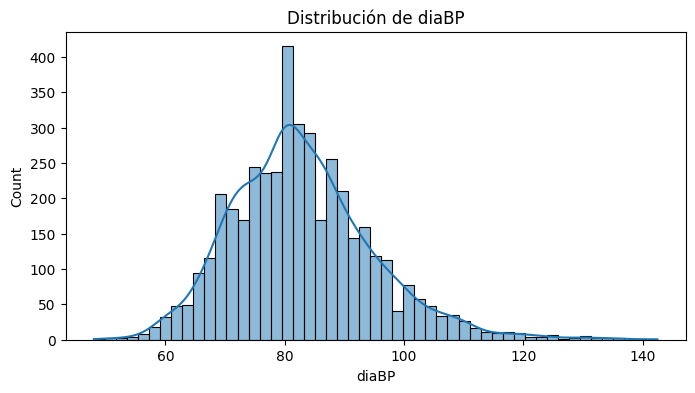

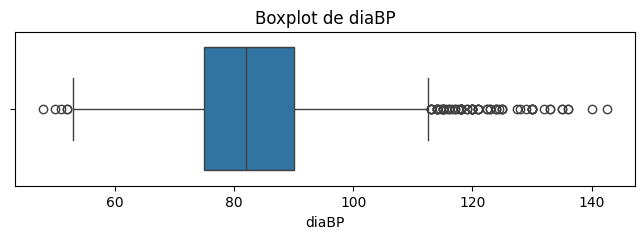

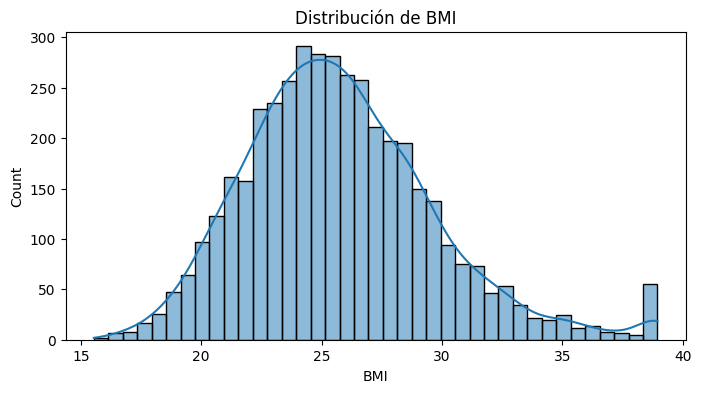

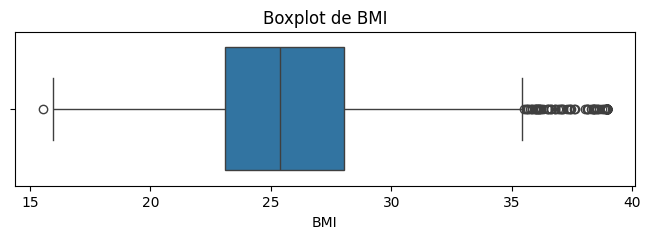

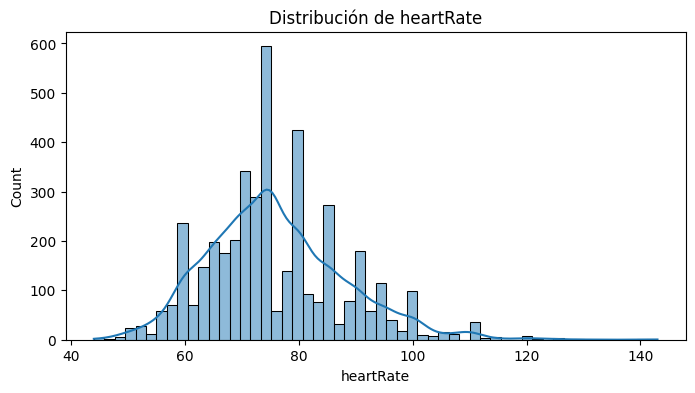

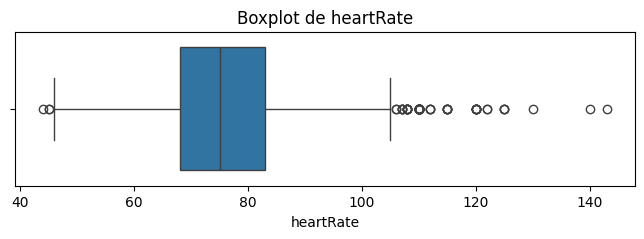

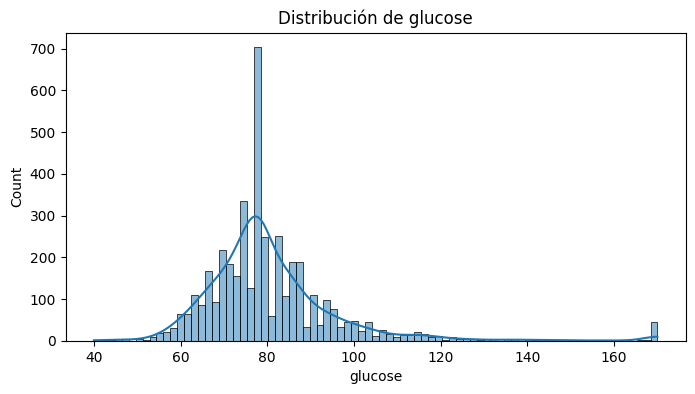

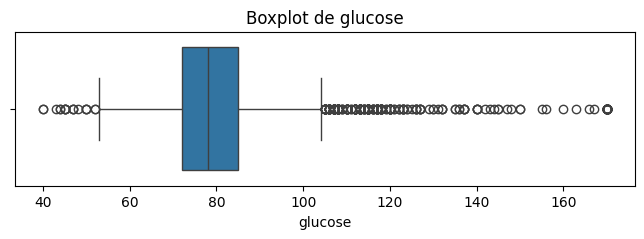

In [36]:
#analisis numericas

for col in numeric_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f'Distribución de {col}')
    
    plt.show()
    
    
    plt.figure(figsize=(8,2))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot de {col}')
    
    plt.show()

se siguen viendo varios outliers en varias categorias pero como probablemente sean relevantes para el modelo y sean datos reales no vamos a tratarlos ya hemos tratado antes los outliers mas grandes. como hemos mencionado antes, algunas variables tienen una concentracion muy alta como puede ser el caso de la glucosa pero glucosa vemos que tambien tiene una dispersion muy elevada ya que presenta valores extremos. 

La variable cigs per day como hemos mencionado antes tiene un pico elevado en el 20 aparte de en el 0 esto genera una clara asimetria de los valores hacia la derecha. como hemos puesto antes esto se puede deber a que 20 es el numero de cigarillos que hay en una cajeta de tabaco.

seguimos con el de las categoricas

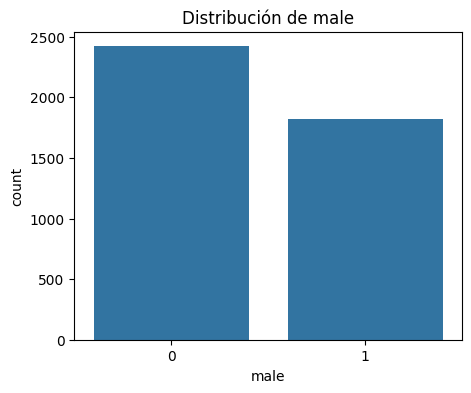

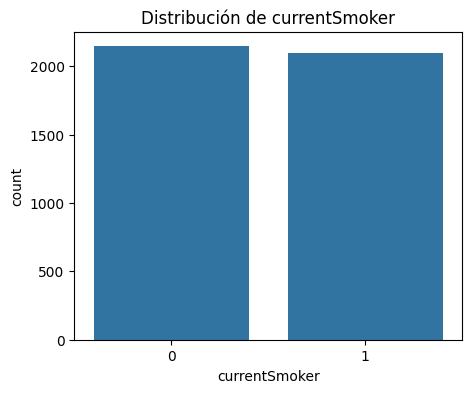

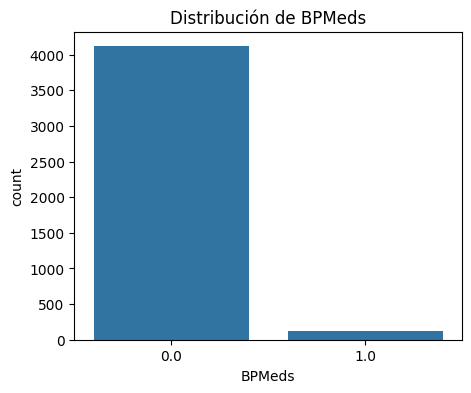

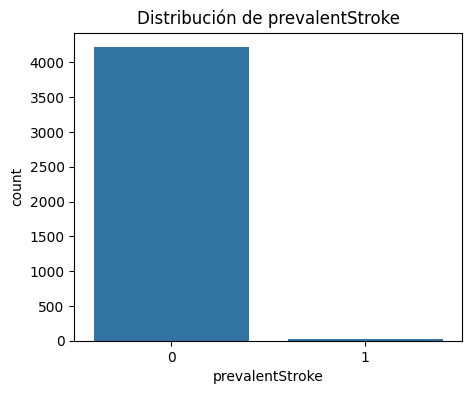

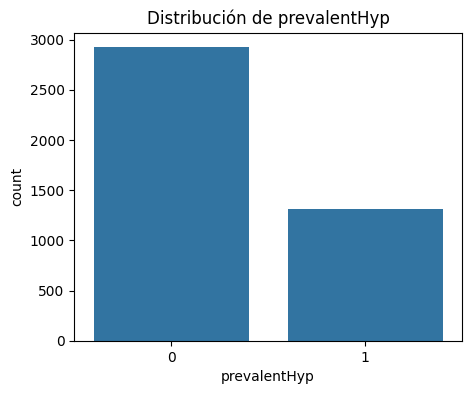

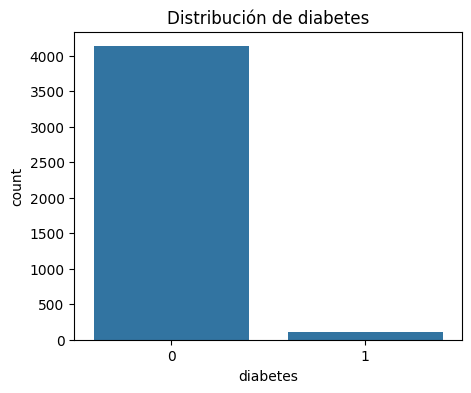

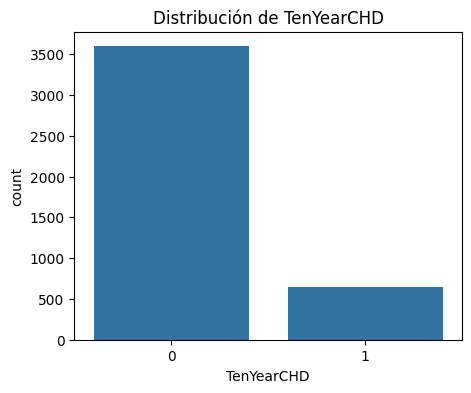

In [21]:
#variables categoricas

for col in categorical_cols:
    
    plt.figure(figsize=(5,4))
    
    sns.countplot(x=df[col])
    
    plt.title(f'Distribución de {col}')
    
    plt.show()

despues de reanalizar las variables podemos ver que varias se encuentran fuertemente desbalanceadas como son los casos de la diabetes, la de previous stroke o la propia variable target que nos dice que no tantas personas desarrollan la enfermedad en 10 años.

Una vez he vuelto a hacer el analisis univariable de todas las variables empezamos con el analisis bivariable

como el propio trabajo nos dice cual es la variable target empezamos a comparar cada variable con ella en este caso es : TenYearCHD

empezamos con numerica vs categorica

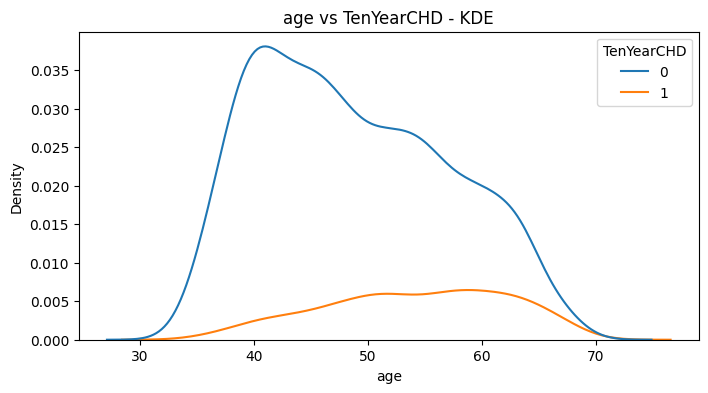

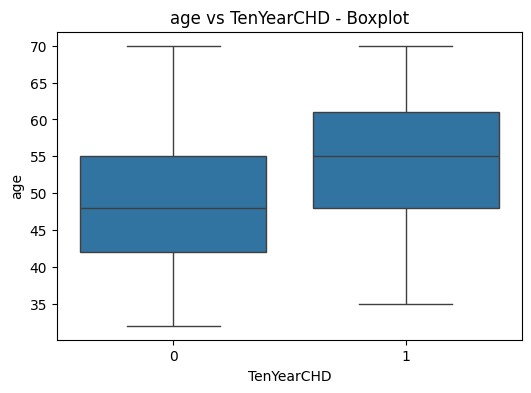

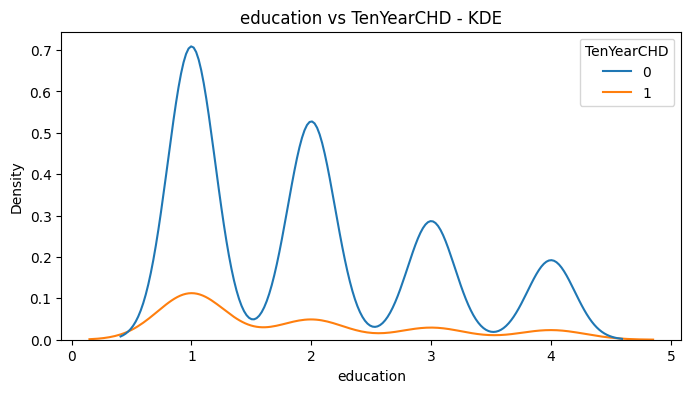

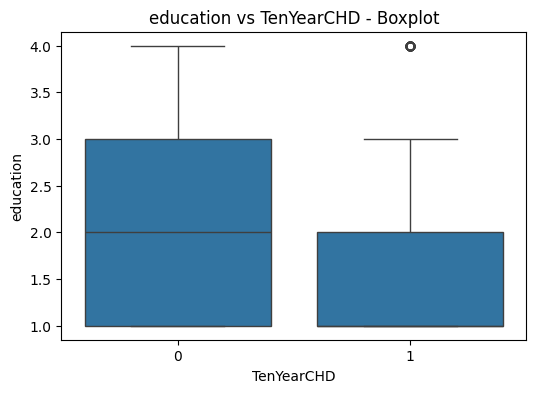

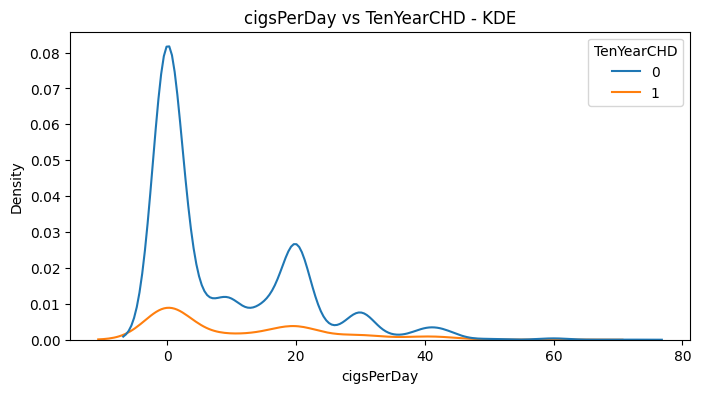

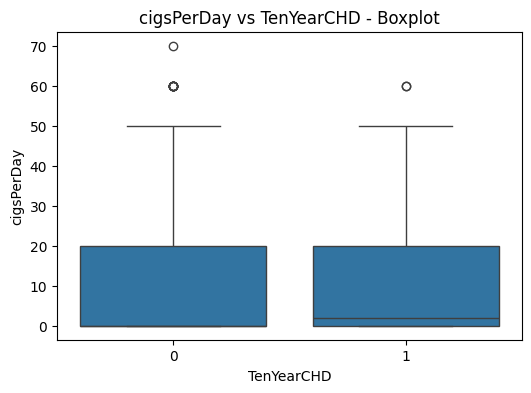

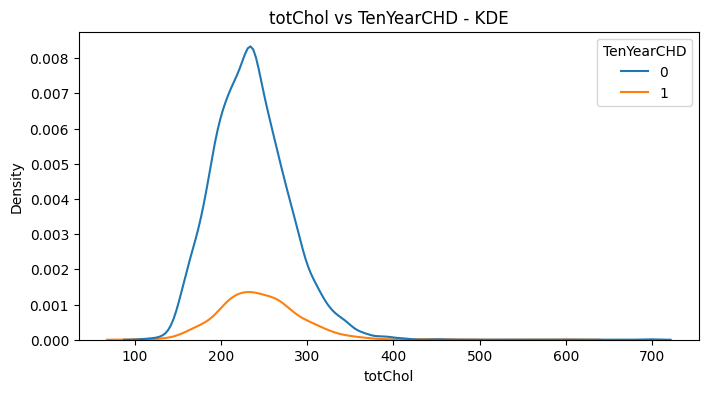

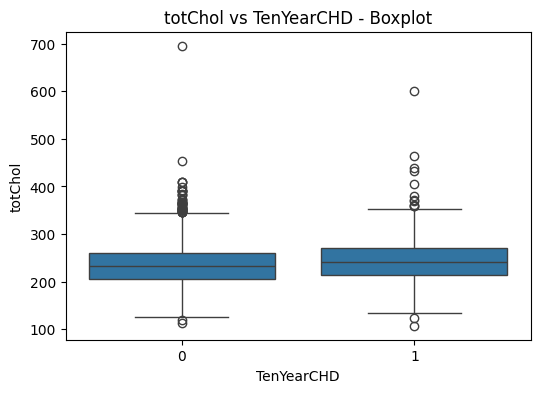

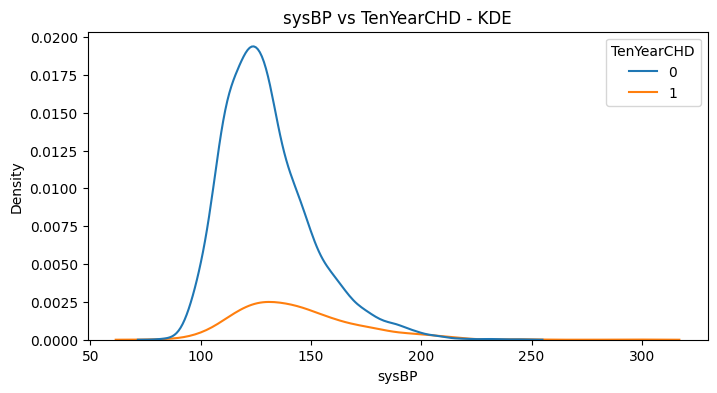

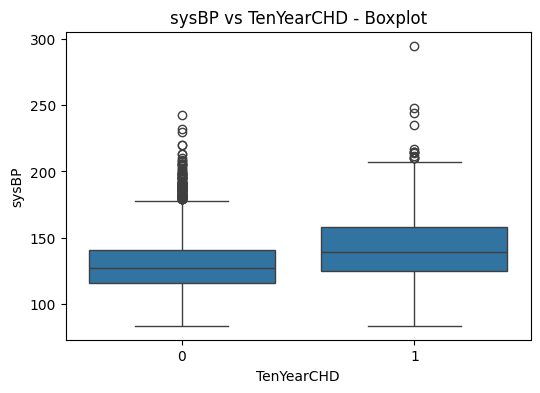

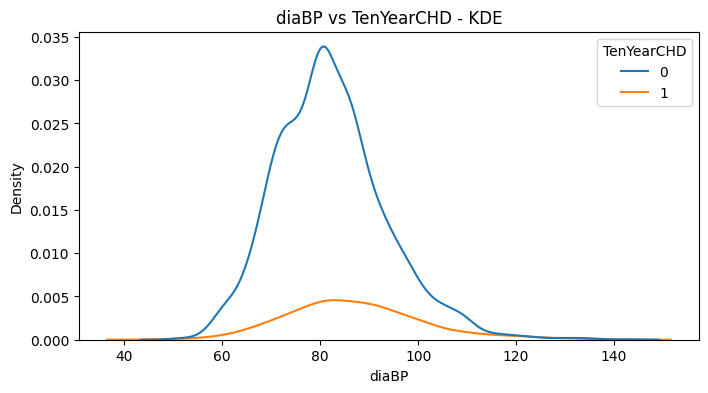

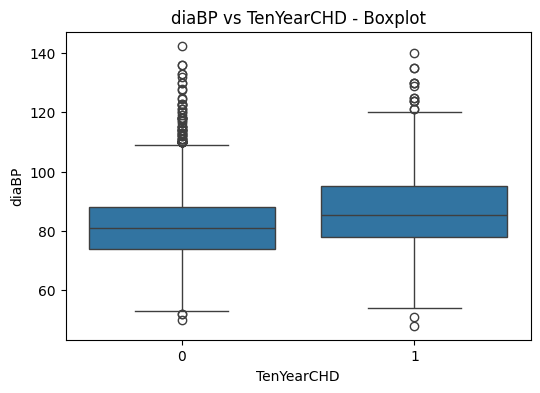

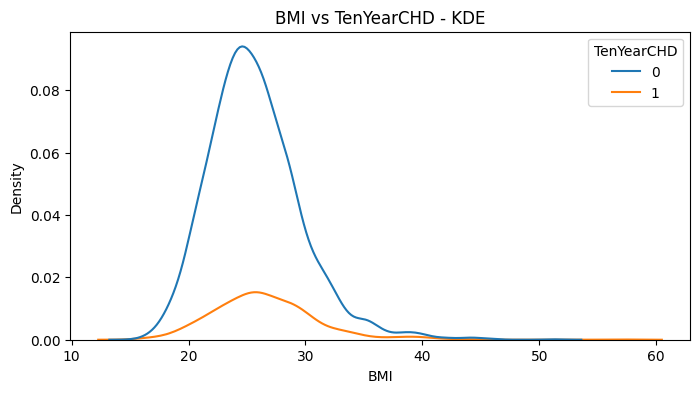

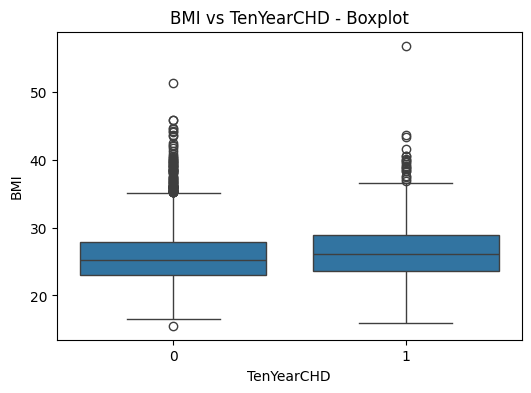

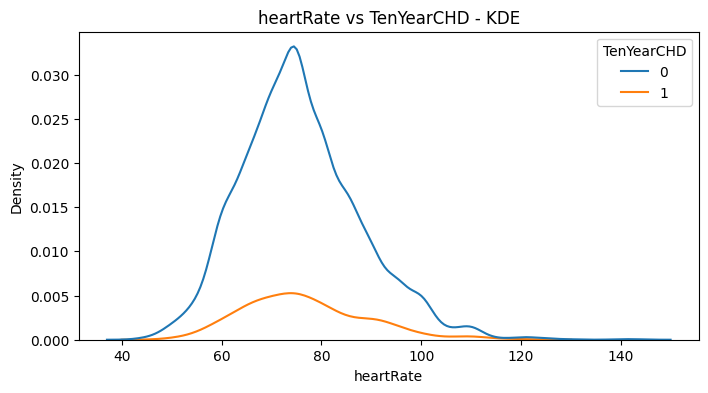

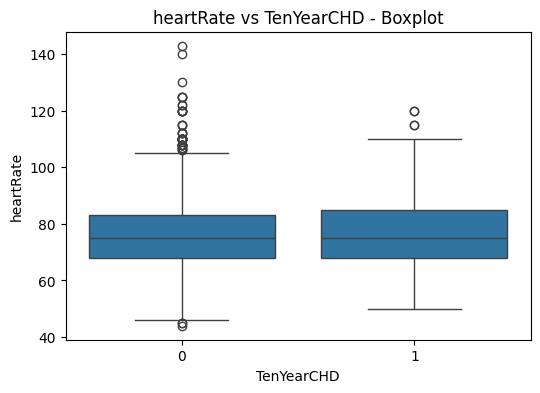

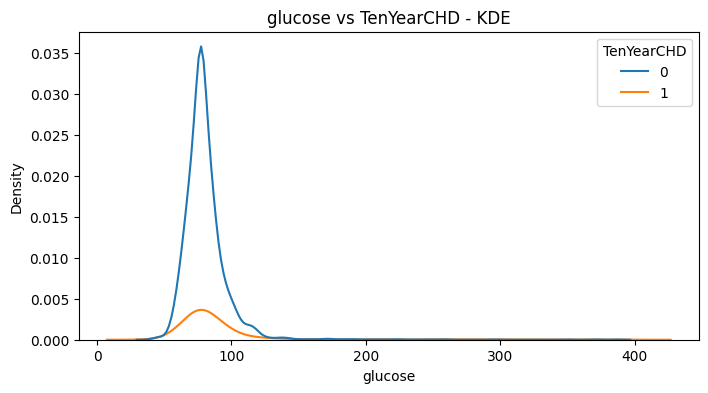

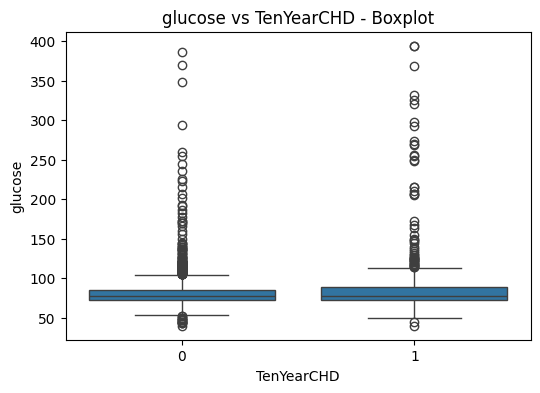

In [26]:
#numerica vs categorica


for col in numeric_cols:
    
    # KDEPLOT
    plt.figure(figsize=(8,4))
    
    sns.kdeplot(data=df, x=col, hue='TenYearCHD')
    
    plt.title(f'{col} vs TenYearCHD - KDE')
    
    plt.show()
    
    
    # BOXPLOT
    plt.figure(figsize=(6,4))
    
    sns.boxplot(data=df, x='TenYearCHD', y=col)
    
    plt.title(f'{col} vs TenYearCHD - Boxplot')
    
    plt.show()

antes de proceder a hacer el anova veo ya algunas cosas interesantes. en el boxplot de sysBP veo que los pacientes con la enfermedad tienden a tener la presion mas alta y valores mayor dispersion. tambien veo claramente que los pacientes de mayor edad presentan mas posibilidades de desarrollar la enfermedad esto se ve por la altura de las medianas en el boxplot tambien.

para medir la relacion entre las variables numericas y la variable target en este caso categorica utilizamos el anova para poder ver el p valor con el objetivo de ver si existen diferencias significativas entre los grupos de pacientes con y sin enfermedad coronaria.

In [23]:


from scipy.stats import f_oneway

for col in numeric_cols:
    
    grupo_0 = df[df['TenYearCHD'] == 0][col]
    
    grupo_1 = df[df['TenYearCHD'] == 1][col]
    
    stat, p = f_oneway(grupo_0, grupo_1)
    
    print(f'\nVariable: {col}')
    print(f'p-value: {p}')


Variable: age
p-value: 5.573313255348953e-50

Variable: education
p-value: 0.0005551369473122304

Variable: cigsPerDay
p-value: 0.0001300534442540288

Variable: totChol
p-value: 9.795875119413243e-08

Variable: sysBP
p-value: 4.217070384051605e-46

Variable: diaBP
p-value: 2.170620368920068e-21

Variable: BMI
p-value: 1.2660451049547772e-06

Variable: heartRate
p-value: 0.13613399710674

Variable: glucose
p-value: 2.2511884601637435e-15


vemos que la mayoria de variables si presentan diferencias significativas entre pacientes con enfermedad y sin enfermedad. en especifico la edad y el sysBp= systolic blood preasure. la variable que no presenta una diferencia es la de heart rate 

ahora procedo a hacer el analisis bivariable entre categoricas con la target

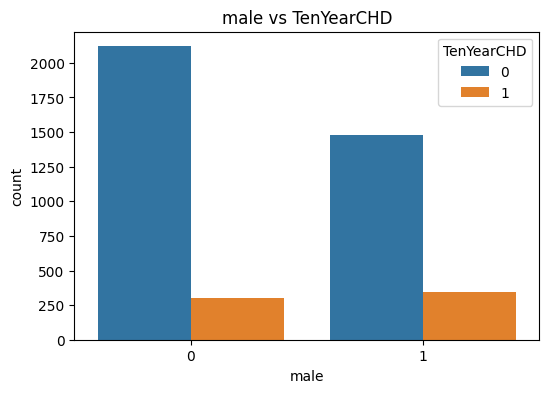

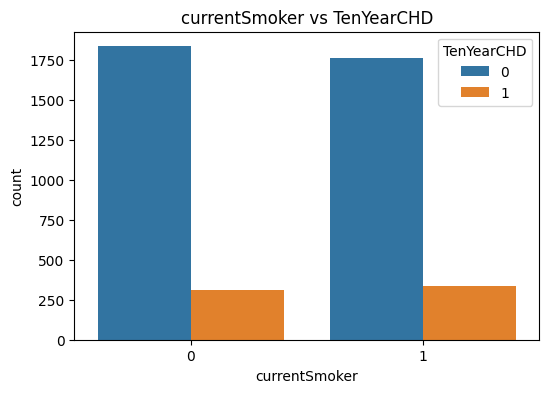

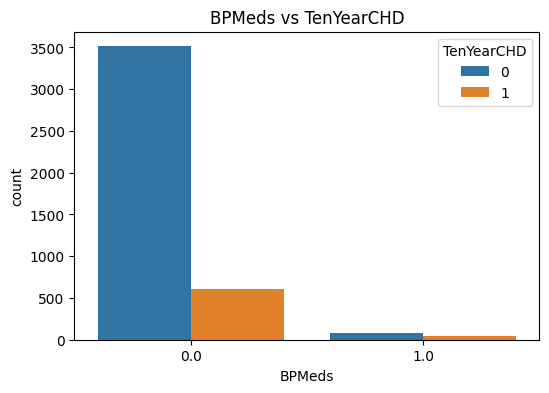

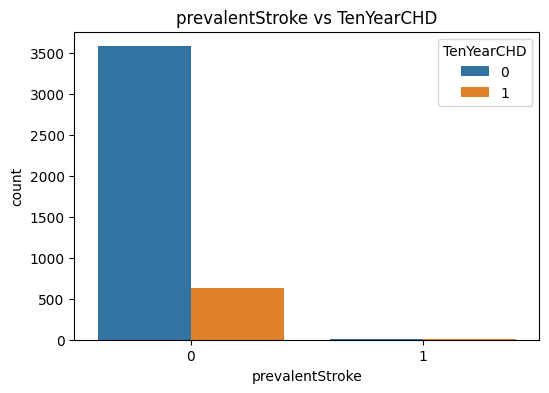

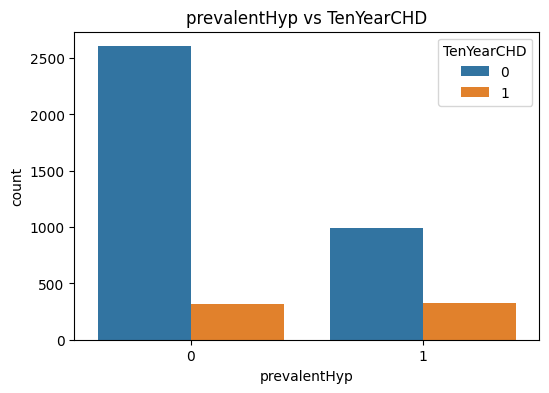

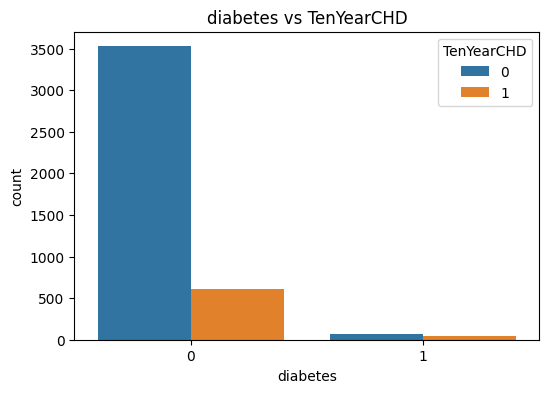

In [24]:
#categoricas vs target

for col in categorical_cols:
    
    if col != 'TenYearCHD':
        
        plt.figure(figsize=(6,4))
        
        sns.countplot(data=df, x=col, hue='TenYearCHD')
        
        plt.title(f'{col} vs TenYearCHD')
        
        plt.show()

hago esta incion para comentar que pese a que tenia en las hipotesis iniciales que no importaba el genero para desarrollar la enfermedad veo que pese a que hay menos hombre el numero de personas con la enfermedad sube. 

hay ciertos graficos donde veo una relacion muy fuerte antes de seguir con crammer o el chi cuadrado como pueden ser las personas con diabetes que han desarrollado la enfermedad y personas que habian tenido un ictus 

ahora hacemos el chi cuadrado para ver si hay relacion en las variables y despues haremos crammer para ver que tan fuertes son esas relaciones. hecho con ia 

In [25]:
#chi cuadrado

for col in categorical_cols:
    
    if col != 'TenYearCHD':
        
        tabla = pd.crosstab(df[col], df['TenYearCHD'])
        
        chi2, p, dof, expected = chi2_contingency(tabla)
        
        print(f'\nVariable: {col}')
        print(f'p-value: {p}')


Variable: male
p-value: 1.1215175755662712e-08

Variable: currentSmoker
p-value: 0.2211021442164888

Variable: BPMeds
p-value: 3.753344425300301e-08

Variable: prevalentStroke
p-value: 0.0001795675785918809

Variable: prevalentHyp
p-value: 1.1889609489706164e-30

Variable: diabetes
p-value: 5.525144036275509e-10


aqui podemos observar que varias variables si tienen relacion existente con la variable objetivo en especial la de prevalentHyp que destaca por su bajo valor. por otro lado la de current smoker no muestra una relacion significativa con la enfermedad. ahora hacemos crammer para ver la fuerza de esas relaciones 

In [27]:
#crammer

for col in categorical_cols:
    
    if col != 'TenYearCHD':
        
        tabla = pd.crosstab(df[col], df['TenYearCHD'])
        
        chi2, p, dof, expected = chi2_contingency(tabla)
        
        n = tabla.sum().sum()
        
        cramers_v = np.sqrt(chi2 / n)
        
        print(f'\nVariable: {col}')
        print(f"Cramer's V: {cramers_v}")


Variable: male
Cramer's V: 0.08770976865023276

Variable: currentSmoker
Cramer's V: 0.01879132894083372

Variable: BPMeds
Cramer's V: 0.08449753719446403

Variable: prevalentStroke
Cramer's V: 0.05753107704405544

Variable: prevalentHyp
Cramer's V: 0.17674753223388678

Variable: diabetes
Cramer's V: 0.09526816439136178


aqui vemos la fuerza de las relaciones de las variables categoricas y la objetivo, como hemos mencionado antes la variable que destaca es la de prevalentHyp con un 0.17 la mas alta de todas. tambien como hemos dicho antes current smoker es la que menos fuerta parece tener en relacion a la enfermedad. 

ahora pasamos a hacer el analisis multivariable 

primero hacemos la matriz de correlacion. hecha con ia

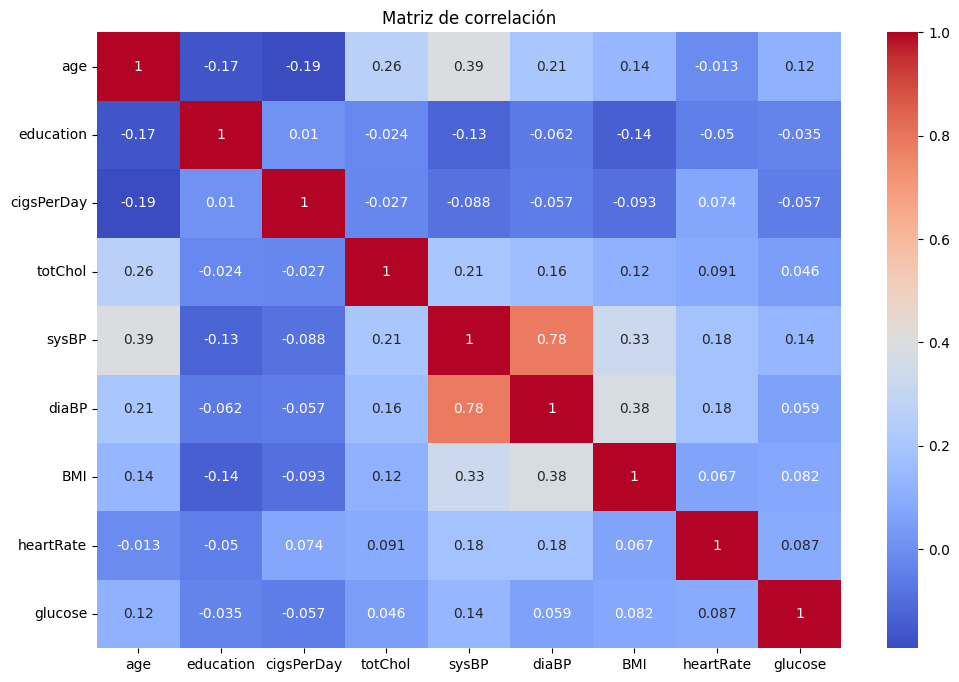

In [28]:
#matriz
plt.figure(figsize=(12,8))

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')

plt.title('Matriz de correlación')

plt.show()

en esta matriz de correlacion se observan fuertes correlaciones como la de sysbp diabp
tambien vemos fuerte correlacion entre age y la presion arterial que nos dice que surge un riesgo cardiovascular con la edad  y la glucosa tiene correlaciones medias con todo el resto de variables 

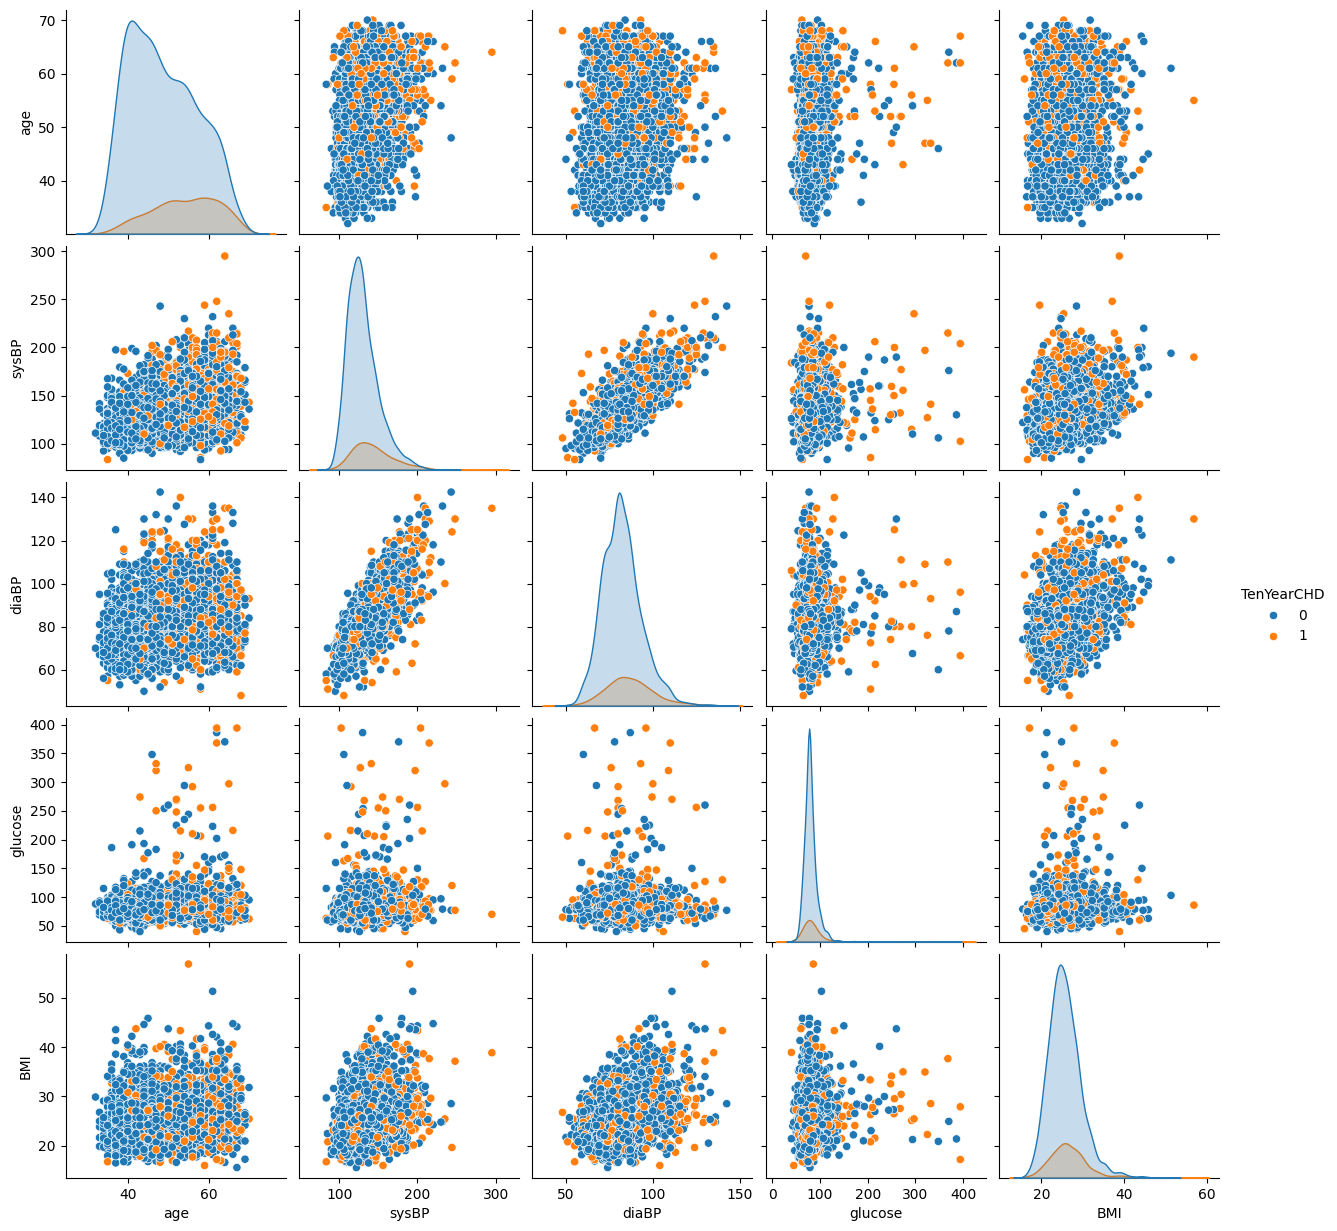

In [ ]:
#pairplot importante

selected_cols = [
    'age',
    'sysBP',
    'diaBP',
    'glucose',
    'BMI',
    'TenYearCHD'
]

sns.pairplot(df[selected_cols], hue='TenYearCHD')

plt.show()

en varios se ve como los pacientes con la enfermedad tienden a concentrarse en zonas de mayor edad y tambien de mayor presion arterial . vemos que la separacion de los grupos no es del todo clara asiq podemos pensar que la enfermedad depende de multiples factores combinados 

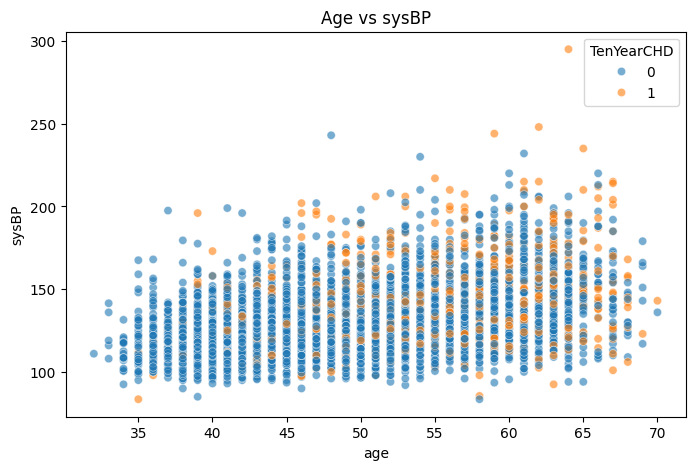

In [ ]:

#age vs sysbp segun target

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='age',
    y='sysBP',
    hue='TenYearCHD',
    alpha=0.6
)

plt.title('Age vs sysBP')

plt.show()

los pacientes se concentran en edades mas elevadas y con valores de presiona arterial superiores 

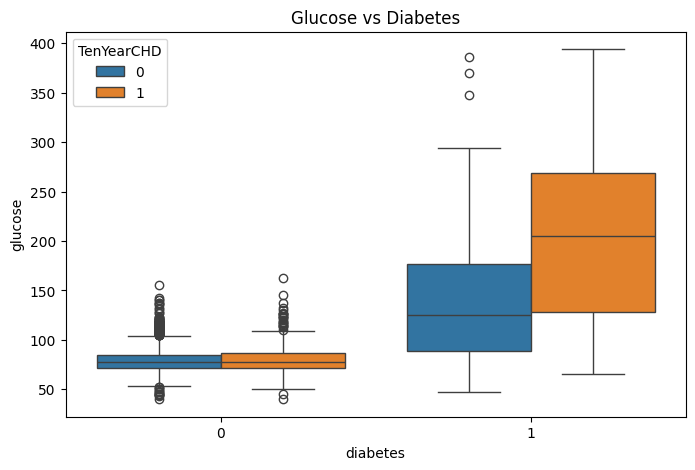

In [ ]:

#glucose y diabetes segun variable y target

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='diabetes',
    y='glucose',
    hue='TenYearCHD'
)

plt.title('Glucose vs Diabetes')

plt.show()

claramente los pacientes diabeticos tienen niveles de glucosa mas elevados como podemos observas por la altura de las medianas especialmente en aquellos que tienen la enfermedad 

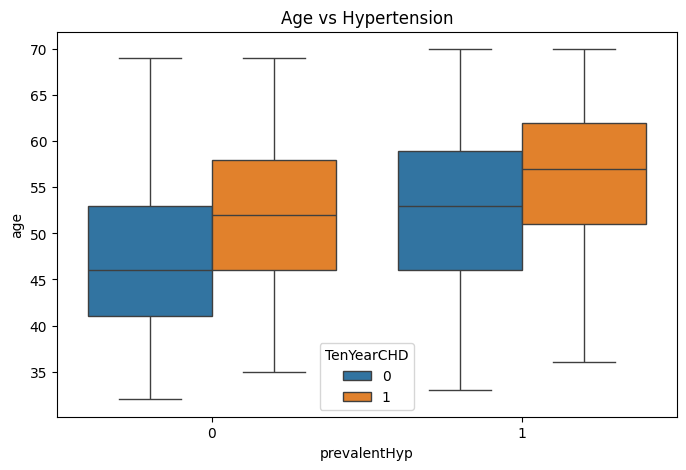

In [ ]:

#age  segun hipertension y target

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='prevalentHyp',
    y='age',
    hue='TenYearCHD'
)

plt.title('Age vs Hypertension')

plt.show()

los pacientes con hipertension son pacientes con edades mas elevadas y tambien tienen mas probabilidad de tener la enfermedad 

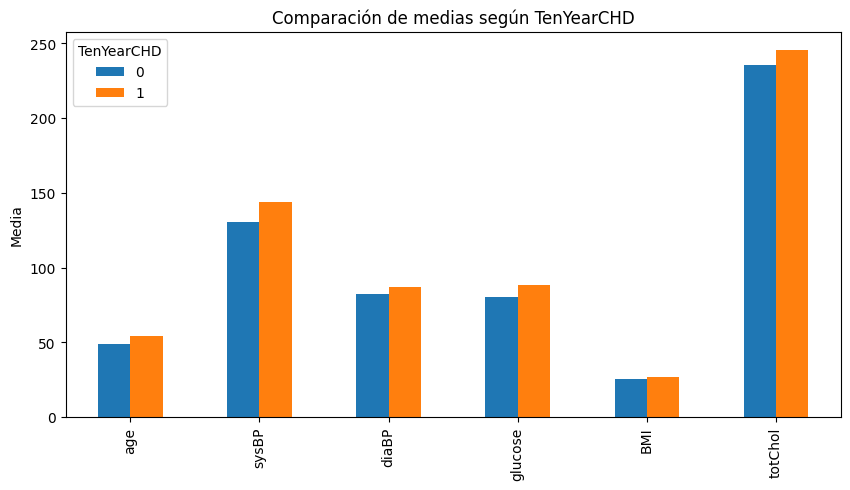

In [ ]:
#comprobacion de medias

df.groupby('TenYearCHD')[
    ['age', 'sysBP', 'diaBP', 'glucose', 'BMI', 'totChol']
].mean().T.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Comparación de medias según TenYearCHD')

plt.ylabel('Media')

plt.show()

el perfil de una persona con la enfermdedad muestra que tiene valores superiores en variables segun su edad presion arterial y la glucosa

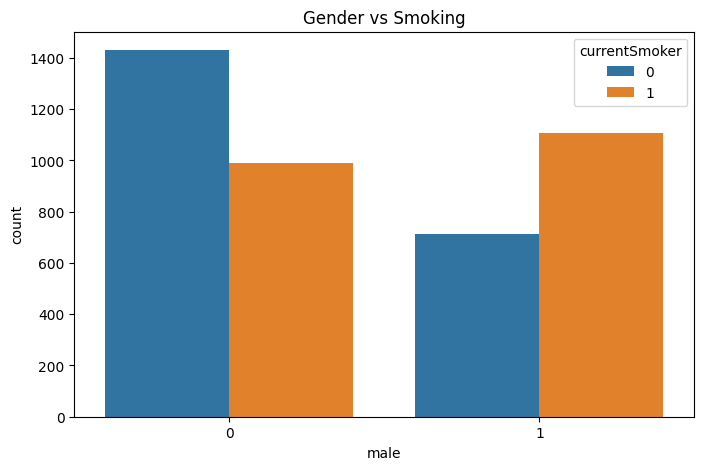

In [ ]:
#ver la de la hipotesis de gender vs smoking vs target

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='male',
    hue='currentSmoker'
)

plt.title('Gender vs Smoking')

plt.show()

se observa que hay una mayor tendencia de fumadores dentro del genero masculino lo que ayuda a explicar porque hay mayor tendencia de la enfermedad en este genero 

vale ahora vamos a hacer las conclusiones contrastandolas con las hipotesis que he hecho al principio del eda. 
1. el tabaquismo aumenta el riesgo cardiovascular queda medianamente confirmada ya que tiene cierta relacion
2.fumar al dia aumenta mas el riesgo queda comprobafo 
3. la diabetes aumenta el riesgo cariovascular queda comprobado que si 
4. un mayor heart rate aumenta el riesgo es falso, n¡la variable no presetna estadisticas. 
5. la educacion si que parece que no tiene tanta importancia pero el genero si que tiene algo que ver parcialemnte 